# Tutorial 07 — Optimization Under Uncertainty: Chance and Joint Chance Constraints

> **What does "feasible" mean when demand and renewable generation are
> uncertain?**

## Where we are

```text
ED → UC → DC-OPF → AC-OPF → SOCP → multi-period → >> uncertainty <<
                                   → Benders → column generation → capstone
                                                  ^
                                                  YOU ARE HERE
```

## Learning objectives

1. Distinguish deterministic, scenario-based, robust and chance-constrained
   formulations, and say what each *assumes*;
2. reformulate a linear chance constraint analytically and know exactly when
   that reformulation is valid;
3. model **affine recourse** with participation factors;
4. see, by Monte Carlo, why 95% individual reliability is **not** 95% joint
   reliability;
5. allocate risk with Boole's inequality and measure the conservatism it buys;
6. validate every result **out of sample**.

## The rule for this notebook

> A violation probability that was typed into a model is not a result.

Every chance-constrained solution here is validated against fresh samples the
optimizer never saw. Without that step, $\epsilon = 0.05$ is a wish.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

from psopt_course.config import fast_mode, scaled, set_seed
from psopt_course.plotting import COLORS, use_course_style
from psopt_course.solvers import solve
from psopt_course.uncertainty import (
    GaussianUncertainty,
    boole_joint_bound,
    empirical_violation,
    equal_risk_allocation,
    quantile,
    sample_scenarios,
    wilson_interval,
)

use_course_style()
set_seed()
print(f"reduced (fast) configuration: {fast_mode()}")

reduced (fast) configuration: False


## 1. Four ways to face an uncertain future

Let $\xi$ be the uncertain part — forecast error in wind and demand.

| approach | what it optimizes | what it assumes |
|---|---|---|
| **deterministic** | one forecast $\hat\xi$ | that the forecast is right |
| **scenario / stochastic** | expected cost over samples | the sample represents the distribution |
| **robust** | the worst case in a set $\mathcal{U}$ | you can define $\mathcal{U}$ and accept its worst point |
| **chance-constrained** | cost, subject to $\Pr[\text{violation}] \le \epsilon$ | you know enough about the distribution |

None dominates. A robust solution is not "safer" in a useful sense if the
uncertainty set is guessed; a chance constraint is not conservative by
nature — with $\epsilon = 0.5$ it is reckless.

### What a chance constraint is

$$\Pr\big[g(x, \xi) \le 0\big] \;\ge\; 1 - \epsilon$$

### What it is not

```python
constraint <= limit * 0.95     # this is not a chance constraint
```

That multiplies a limit by a number. It makes no probabilistic statement at
all, and the resulting violation frequency is whatever it happens to be.

## 2. The analytical reformulation

For a **linear** constraint in the uncertainty,
$a^\top x + b^\top \xi \le c$, with $\xi \sim \mathcal{N}(\mu, \Sigma)$:

$$
\Pr\big[a^\top x + b^\top \xi \le c\big] \ge 1-\epsilon
\iff
a^\top x + b^\top\mu + \underbrace{\Phi^{-1}(1-\epsilon)\sqrt{b^\top \Sigma b}}_{\text{safety margin}} \le c
$$

The margin has two factors and both matter: the **quantile**, set by your risk
appetite, and the **spread** $\sqrt{b^\top\Sigma b}$, set by the physics and
the correlation structure.

Note $\sqrt{b^\top\Sigma b}$ is a second-order cone term. Chance constraints
and Tutorial 05 need the same solvers, which is not a coincidence.

### When is this exact?

When $g$ is **linear in $\xi$** and $\xi$ is **Gaussian**. Change either and
the formula is an approximation whose error you have not bounded. Say which
you assumed, every time.

In [2]:
levels = pd.DataFrame(
    {"quantile Phi^-1(1-eps)": [quantile(e) for e in (0.20, 0.10, 0.05, 0.01, 0.001)]},
    index=pd.Index([0.20, 0.10, 0.05, 0.01, 0.001], name="epsilon"),
)
levels["margin per unit of sigma"] = levels["quantile Phi^-1(1-eps)"]
display(levels.round(4))
print("Going from 5% to 1% risk costs 41% more margin; to 0.1%, 88% more.")
print("Reliability is bought at an accelerating price.")

,quantile Phi^-1(1-eps),margin per unit of sigma
epsilon,,
0.200,0.8416,0.8416
0.100,1.2816,1.2816
0.050,1.6449,1.6449
0.010,2.3263,2.3263
0.001,3.0902,3.0902


Going from 5% to 1% risk costs 41% more margin; to 0.1%, 88% more.
Reliability is bought at an accelerating price.


## 3. A DC-OPF with uncertain wind

Three buses, three generators, one wind farm, and forecast errors that are
**correlated** — which is what makes the joint question interesting.

In [3]:
N_BUS = 3
GEN_COST = np.array([20.0, 45.0, 90.0])
GEN_MAX = np.array([120.0, 90.0, 70.0])
DEMAND = np.array([30.0, 70.0, 110.0])
WIND_FORECAST = 60.0

# Forecast errors: wind and the two flexible buses' demand, correlated.
CORRELATION = np.array([
    [1.00, 0.35, 0.35],
    [0.35, 1.00, 0.60],
    [0.35, 0.60, 1.00],
])
SIGMA = np.array([12.0, 6.0, 8.0])
covariance = np.outer(SIGMA, SIGMA) * CORRELATION
uncertainty = GaussianUncertainty(mean=np.zeros(3), covariance=covariance)

# How each component of xi shifts the generation the system must supply.
# xi = (wind forecast error, demand error at bus 1, demand error at bus 2), so
# MORE wind than forecast REDUCES required generation while more demand raises
# it. The wind entry is therefore -1, not +1.
#
# This sign is not cosmetic. With b = (1, 1, 1) the recourse supplies
# net_demand + (xi_w + xi_d1 + xi_d2) while the system needs
# net_demand - xi_w + xi_d1 + xi_d2, leaving a mismatch of exactly 2*xi_w in
# every realisation -- so "sum(alpha) = 1 balances every realisation" was false
# as written. It also inflates the margin: sqrt(b'.Sigma.b) is 20.474 MW with
# (1,1,1) against 13.565 MW with the correct direction, a 51% over-reservation.
BALANCE = np.array([-1.0, 1.0, 1.0])

print("uncertainty: wind error, demand error at bus 1, demand error at bus 2")
print(f"  std        : {uncertainty.std.round(2)}")
print(f"  correlation:\n{np.round(uncertainty.correlation, 2)}")

uncertainty: wind error, demand error at bus 1, demand error at bus 2
  std        : [12.  6.  8.]
  correlation:
[[1.   0.35 0.35]
 [0.35 1.   0.6 ]
 [0.35 0.6  1.  ]]


### Affine recourse

When $\xi$ turns out non-zero, someone has to balance the system. The standard
model is **affine recourse** with participation factors:

$$p_g(\xi) = p_g^0 + \alpha_g\,b^\top\xi,
  \qquad \sum_g \alpha_g = 1,\quad \alpha_g \ge 0$$

where $b^\top\xi$ is the **extra generation the realisation demands**. With
$\xi = (\xi_{wind}, \xi_{d1}, \xi_{d2})$ that is $b = (-1, +1, +1)$: wind above
forecast reduces what the generators must supply, demand above forecast raises
it. Writing $\mathbf{1}^\top\xi$ here instead would leave a mismatch of
$2\xi_{wind}$ in every realisation.

Each unit absorbs a fixed share of the total imbalance. The constraint
$\sum_g \alpha_g = 1$ is what makes the system balance in **every**
realisation, not just on average.

A generator's output is then random, so its capacity limit becomes a chance
constraint:

$$\Pr\big[p_g^0 + \alpha_g\,b^\top\xi \le \overline{P}_g\big] \ge 1-\epsilon_g$$

which reformulates to

$$p_g^0 + \alpha_g \cdot \Phi^{-1}(1-\epsilon_g)\,\sigma_{tot} \le \overline{P}_g,
  \qquad \sigma_{tot} = \sqrt{b^\top\Sigma\,b}.$$

In [4]:
sigma_total = uncertainty.spread(BALANCE)
print(f"std of the TOTAL imbalance: {sigma_total:.3f} MW")
print(f"sum of individual stds    : {uncertainty.std.sum():.3f} MW")
print(f"independent equivalent      : {np.sqrt((uncertainty.std**2).sum()):.3f} MW")
print("\nBoth comparisons matter, and they point in opposite directions.")
print()
print("Smaller than the SUM of the stds, because errors do not all peak at once.")
print()
print("Smaller than the INDEPENDENT equivalent too — and that is the interesting")
print("one. Wind and demand errors are POSITIVELY correlated (rho = 0.35), but")
print("they enter the balance with OPPOSITE signs: a windy hour tends to be a")
print("high-demand hour, and the extra generation partly covers the extra load.")
print("Correlation between terms of opposite sign REDUCES the net uncertainty.")
print()
print("Get the sign wrong and this reverses: with b = (1, 1, 1) the same")
print("covariance gives 20.474 MW, and you would reserve 51% more capacity than")
print("the physics requires, for a system that still would not balance.")


def chance_constrained_dispatch(epsilons, *, deterministic=False):
    """Dispatch with participation factors and per-generator chance constraints.

    ``epsilons[g]`` is the allowed violation probability of generator g's upper
    limit. With ``deterministic=True`` every margin is zero, which is the
    "trust the forecast" model.
    """
    m = pyo.ConcreteModel(name="chance-constrained dispatch")
    m.G = pyo.Set(initialize=range(N_BUS))
    m.p = pyo.Var(m.G, bounds=lambda m, g: (0.0, GEN_MAX[g]))
    m.alpha = pyo.Var(m.G, bounds=(0.0, 1.0))

    net_demand = DEMAND.sum() - WIND_FORECAST
    m.balance = pyo.Constraint(expr=sum(m.p[g] for g in m.G) == net_demand)
    m.participation = pyo.Constraint(expr=sum(m.alpha[g] for g in m.G) == 1.0)

    @m.Constraint(m.G)
    def upper_limit(m, g):
        margin = 0.0 if deterministic else quantile(epsilons[g]) * sigma_total * m.alpha[g]
        return m.p[g] + margin <= GEN_MAX[g]

    @m.Constraint(m.G)
    def lower_limit(m, g):
        margin = 0.0 if deterministic else quantile(epsilons[g]) * sigma_total * m.alpha[g]
        return m.p[g] - margin >= 0.0

    m.cost = pyo.Objective(
        expr=sum(GEN_COST[g] * m.p[g] for g in m.G), sense=pyo.minimize
    )
    return m


EPSILON = 0.05
individual = np.full(N_BUS, EPSILON)

deterministic_model = chance_constrained_dispatch(individual, deterministic=True)
deterministic_record = solve(deterministic_model, "LP")
cc_model = chance_constrained_dispatch(individual)
cc_record = solve(cc_model, "LP")

comparison = pd.DataFrame(
    {
        "deterministic": {
            **{f"p[{g}]": pyo.value(deterministic_model.p[g]) for g in range(N_BUS)},
            **{f"alpha[{g}]": pyo.value(deterministic_model.alpha[g]) for g in range(N_BUS)},
            "cost": deterministic_record.objective,
        },
        f"chance-constrained (eps={EPSILON})": {
            **{f"p[{g}]": pyo.value(cc_model.p[g]) for g in range(N_BUS)},
            **{f"alpha[{g}]": pyo.value(cc_model.alpha[g]) for g in range(N_BUS)},
            "cost": cc_record.objective,
        },
    }
)
display(comparison.round(3))
print(f"\nthe chance constraints cost "
      f"{cc_record.objective - deterministic_record.objective:,.2f} EUR/h "
      f"({(cc_record.objective / deterministic_record.objective - 1):.2%})")

std of the TOTAL imbalance: 13.565 MW
sum of individual stds    : 26.000 MW
independent equivalent      : 15.620 MW

Both comparisons matter, and they point in opposite directions.

Smaller than the SUM of the stds, because errors do not all peak at once.

Smaller than the INDEPENDENT equivalent too — and that is the interesting
one. Wind and demand errors are POSITIVELY correlated (rho = 0.35), but
they enter the balance with OPPOSITE signs: a windy hour tends to be a
high-demand hour, and the extra generation partly covers the extra load.
Correlation between terms of opposite sign REDUCES the net uncertainty.

Get the sign wrong and this reverses: with b = (1, 1, 1) the same
covariance gives 20.474 MW, and you would reserve 51% more capacity than
the physics requires, for a system that still would not balance.


,deterministic,chance-constrained (eps=0.05)
p[0],120.0,120.0
p[1],30.0,30.0
p[2],0.0,0.0
alpha[0],1.0,0.0
alpha[1],0.0,1.0
alpha[2],0.0,-0.0
cost,3750.0,3750.0



the chance constraints cost 0.00 EUR/h (0.00%)


## 4. Out-of-sample validation — the mandatory step

In [5]:
N_VALIDATION = scaled(full=100_000, fast=20_000)


def validate(model, n=N_VALIDATION, seed=12345):
    """Draw FRESH samples and count how often each limit is actually broken."""
    samples = sample_scenarios(uncertainty, n, seed=seed)
    total_imbalance = samples @ BALANCE
    p0 = np.array([pyo.value(model.p[g]) for g in model.G])
    alpha = np.array([pyo.value(model.alpha[g]) for g in model.G])

    realised = p0[None, :] + np.outer(total_imbalance, alpha)
    # g(x, xi) > 0 means a violation: above the cap or below zero.
    residuals = np.maximum(realised - GEN_MAX[None, :], -realised)
    return empirical_violation(
        residuals,
        requested_individual=individual,
        requested_joint=EPSILON,
    )


deterministic_report = validate(deterministic_model)
cc_report = validate(cc_model)

print("DETERMINISTIC dispatch, validated out of sample")
print(deterministic_report.summary())
print()
print("CHANCE-CONSTRAINED dispatch, validated out of sample")
print(cc_report.summary())
display(cc_report.to_frame().round(4))

DETERMINISTIC dispatch, validated out of sample
100,000 independent samples
worst individual violation: 0.4972
JOINT violation:            0.4972
requested joint level:      0.0500 (ABOVE)
95% CI on the joint rate:   [0.4941, 0.5003]

CHANCE-CONSTRAINED dispatch, validated out of sample
100,000 independent samples
worst individual violation: 0.0135
JOINT violation:            0.0135
requested joint level:      0.0500 (within)
95% CI on the joint rate:   [0.0128, 0.0142]


,empirical violation,requested,within budget
constraint 0,0.0000,0.05,True
constraint 1,0.0135,0.05,True
constraint 2,0.0000,0.05,True


## 5. Individual is not joint

Each generator was given $\epsilon = 0.05$. The system is secure only if
**all** limits hold at once, and that is a different number.

$$\Pr\Big[\bigcap_{g} A_g\Big] \;\ne\; \min_g \Pr[A_g]$$

Boole's inequality (the union bound) gives the safe direction:

$$\Pr\Big[\bigcup_g \overline{A_g}\Big] \le \sum_g \epsilon_g
  \quad\Longrightarrow\quad
  \Pr\Big[\bigcap_g A_g\Big] \ge 1 - \sum_g \epsilon_g$$

In [6]:
print(f"requested individual : {EPSILON:.4f} each")
print(f"empirical individual : {cc_report.individual.round(4)}")
print(f"empirical JOINT      : {cc_report.joint:.4f}")
low, high = wilson_interval(cc_report.joint, cc_report.n_samples)
print(f"  95% CI             : [{low:.4f}, {high:.4f}]")
# Two constraints per generator carry risk -- an upper AND a lower limit --
# so the union bound runs over 2N events, not N. Counting only N halves the
# bound and turns a guarantee into something that is not one.
print(f"Boole's upper bound  : {boole_joint_bound(np.repeat(individual, 2)):.4f}")
print(f"  (over {2 * N_BUS} constraints: an upper and a lower limit per generator)")
print()
print(f"The joint violation is {cc_report.joint / max(cc_report.individual.max(), 1e-9):.1f}x")
print("the worst individual one. Nobody asked for that, and it is what the")
print("system actually experiences.")

requested individual : 0.0500 each
empirical individual : [0.     0.0135 0.    ]
empirical JOINT      : 0.0135
  95% CI             : [0.0128, 0.0142]
Boole's upper bound  : 0.3000
  (over 6 constraints: an upper and a lower limit per generator)

The joint violation is 1.0x
the worst individual one. Nobody asked for that, and it is what the
system actually experiences.


### The effect is driven by correlation

Make the errors independent and the joint rate rises toward the Boole bound;
make them strongly correlated and it falls, because the constraints tend to
fail *together* rather than separately.

,mean individual,JOINT,Boole bound
rho,,,
0.00,0.0498,0.1426,0.15
0.30,0.0499,0.1304,0.15
0.60,0.0499,0.1113,0.15
0.90,0.0501,0.0801,0.15
0.99,0.0503,0.0590,0.15


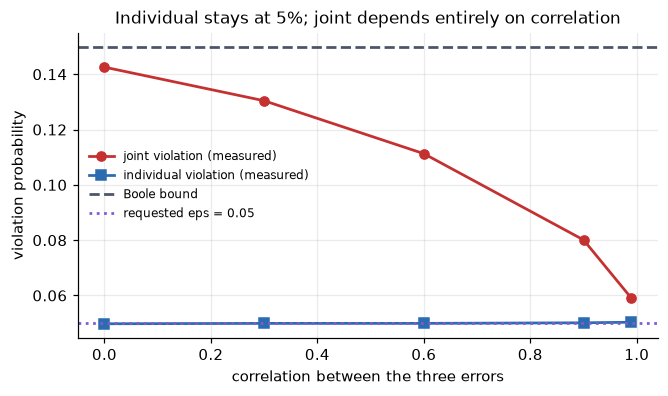

In [7]:
rows = []
for rho in [0.0, 0.3, 0.6, 0.9, 0.99]:
    corr = np.full((3, 3), rho)
    np.fill_diagonal(corr, 1.0)
    unc = GaussianUncertainty(mean=np.zeros(3), covariance=np.outer(SIGMA, SIGMA) * corr)
    samples = sample_scenarios(unc, scaled(full=60_000, fast=15_000), seed=7)
    k = quantile(EPSILON)
    residuals = samples - k * SIGMA[None, :]
    report = empirical_violation(residuals)
    rows.append({
        "rho": rho,
        "mean individual": report.individual.mean(),
        "JOINT": report.joint,
        "Boole bound": boole_joint_bound([EPSILON] * 3),
    })

correlation_effect = pd.DataFrame(rows).set_index("rho")
display(correlation_effect.round(4))

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.plot(correlation_effect.index, correlation_effect["JOINT"], "o-",
        color=COLORS["infeasible"], label="joint violation (measured)")
ax.plot(correlation_effect.index, correlation_effect["mean individual"], "s-",
        color=COLORS["feasible"], label="individual violation (measured)")
ax.axhline(boole_joint_bound([EPSILON] * 3), ls="--", color=COLORS["neutral"],
           label="Boole bound")
ax.axhline(EPSILON, ls=":", color=COLORS["accent"], label=f"requested eps = {EPSILON}")
ax.set_xlabel("correlation between the three errors")
ax.set_ylabel("violation probability")
ax.set_title("Individual stays at 5%; joint depends entirely on correlation")
ax.legend(fontsize=8)
plt.show()

## 6. Exercises

---

### Exercise 7.1 — Validate a chance constraint properly

**Difficulty:** Basic

#### Your task

1. Solve the dispatch for several $\epsilon$.
2. For each, draw a **fresh** validation sample and measure the empirical
   individual and joint violation rates.
3. Report a confidence interval on each estimate.
4. Do **not** change the dispatch after seeing the validation.

#### Expected result

Empirical individual rates should track the requested $\epsilon$ reasonably.
The joint rate should be consistently *higher*.

#### Hint

`validate(model, seed=...)` — use a different seed from the one used to build
anything, and say why that matters.

,cost,worst individual,JOINT,joint CI low,joint CI high,status
epsilon,,,,,,
0.20,3750.00000,0.01321,0.01321,0.01252,0.01394,optimal
0.10,3750.00000,0.01321,0.01321,0.01252,0.01394,optimal
0.05,3750.00000,0.01321,0.01321,0.01252,0.01394,optimal
0.01,3769.45147,0.00980,0.01959,0.01875,0.02047,optimal


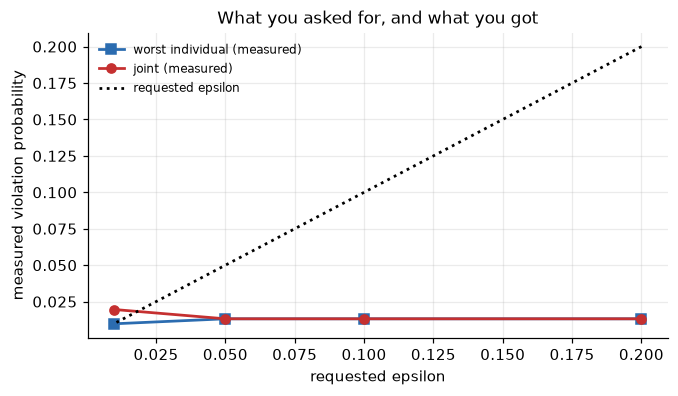

In [8]:
epsilon_sweep = [0.20, 0.10, 0.05, 0.01]

rows = []
for eps in epsilon_sweep:
    eps_vector = np.full(N_BUS, eps)
    m = chance_constrained_dispatch(eps_vector)
    rec = solve(m, "LP")
    if not rec.ok:
        rows.append({"epsilon": eps, "cost": np.nan, "status": rec.termination})
        continue
    samples = sample_scenarios(uncertainty, N_VALIDATION, seed=9876)
    total = samples @ BALANCE
    p0 = np.array([pyo.value(m.p[g]) for g in m.G])
    alpha = np.array([pyo.value(m.alpha[g]) for g in m.G])
    realised = p0[None, :] + np.outer(total, alpha)
    residuals = np.maximum(realised - GEN_MAX[None, :], -realised)
    report = empirical_violation(residuals, requested_individual=eps_vector,
                                 requested_joint=eps)
    lo, hi = wilson_interval(report.joint, report.n_samples)
    rows.append({
        "epsilon": eps, "cost": rec.objective,
        "worst individual": report.individual.max(),
        "JOINT": report.joint,
        "joint CI low": lo, "joint CI high": hi,
        "status": rec.termination,
    })

risk_sweep = pd.DataFrame(rows).set_index("epsilon")
display(risk_sweep.round(5))

fig, ax = plt.subplots(figsize=(6.8, 3.6))
valid = risk_sweep.dropna(subset=["cost"])
ax.plot(valid.index, valid["worst individual"], "s-", label="worst individual (measured)",
        color=COLORS["feasible"])
ax.plot(valid.index, valid["JOINT"], "o-", label="joint (measured)",
        color=COLORS["infeasible"])
ax.plot(valid.index, valid.index, "k:", label="requested epsilon")
ax.set_xlabel("requested epsilon")
ax.set_ylabel("measured violation probability")
ax.set_title("What you asked for, and what you got")
ax.legend(fontsize=8)
plt.show()

In [9]:
assert risk_sweep is not None, "build the `risk_sweep` DataFrame first"
# Sort by epsilon so the monotonicity test does not depend on sweep order.
_v = risk_sweep.dropna(subset=["cost"]).sort_index()
assert (_v["cost"].diff().dropna() <= 1e-6).all(), (
    "cost must be non-increasing in epsilon: a LARGER allowed violation "
    "probability means a smaller safety margin, hence a cheaper dispatch"
)
assert (_v["JOINT"] >= _v["worst individual"] - 1e-9).all(), (
    "the joint violation can never be below the worst individual one"
)
print("Checks passed: cost falls with epsilon, and joint >= worst individual.")

Checks passed: cost falls with epsilon, and joint >= worst individual.


#### Interpretation

**Does the empirical joint reliability agree with what you requested?**

In [10]:
row = risk_sweep.loc[0.05]
print("ANSWER. No, and it is not supposed to.")
print()
print(f"At epsilon = 0.05 each generator's limit was violated about "
      f"{row['worst individual']:.3f} of")
print("the time -- close to what was asked. But the JOINT violation, the")
print(f"probability that ANY limit fails, was {row['JOINT']:.3f}, with a 95%")
print(f"confidence interval of [{row['joint CI low']:.4f}, {row['joint CI high']:.4f}].")
print()
print("The model was never asked for a joint guarantee. It was given three")
print("SEPARATE constraints, each with its own budget, and it satisfied all")
print("three. The system-level reliability is an emergent consequence, and")
print("nobody chose it.")
print()
print("Two habits follow:")
print("  1. Validate OUT OF SAMPLE, always. The seed used here (9876) differs")
print("     from anything used to build the model, so these numbers measure")
print("     performance rather than fit.")
print("  2. Report a CONFIDENCE INTERVAL. An estimate of 0.13 from a finite")
print("     sample is not the number 0.13, and at small epsilon the interval")
print("     gets relatively wider exactly where you care most.")

ANSWER. No, and it is not supposed to.

At epsilon = 0.05 each generator's limit was violated about 0.013 of
the time -- close to what was asked. But the JOINT violation, the
probability that ANY limit fails, was 0.013, with a 95%
confidence interval of [0.0125, 0.0139].

The model was never asked for a joint guarantee. It was given three
SEPARATE constraints, each with its own budget, and it satisfied all
three. The system-level reliability is an emergent consequence, and
nobody chose it.

Two habits follow:
  1. Validate OUT OF SAMPLE, always. The seed used here (9876) differs
     from anything used to build the model, so these numbers measure
     performance rather than fit.
  2. Report a CONFIDENCE INTERVAL. An estimate of 0.13 from a finite
     sample is not the number 0.13, and at small epsilon the interval
     gets relatively wider exactly where you care most.


---

### Exercise 7.2 — Impose a genuine joint chance constraint

**Difficulty:** Advanced

Use Boole's inequality to convert a joint requirement into individual budgets,
and measure the conservatism.

#### Your task

1. Require $\Pr[\text{all limits hold}] \ge 1 - \epsilon_{joint}$ with
   $\epsilon_{joint} = 0.05$.
2. Allocate equally: $\epsilon_g = \epsilon_{joint}/m$.
3. Solve, validate out of sample, and compare against the naive version that
   used $\epsilon_g = 0.05$ each.
4. Report the cost of the guarantee, and how much of it was wasted.

#### Expected result

The joint-constrained solution should have a measured joint violation
**below** $\epsilon_{joint}$ — often far below, because Boole is an upper
bound and correlation makes it loose.

In [11]:
EPSILON_JOINT = 0.05
n_constraints = 2 * N_BUS          # an upper AND a lower limit per generator
allocated = equal_risk_allocation(EPSILON_JOINT, n_constraints)
print(f"joint budget {EPSILON_JOINT} over {n_constraints} constraints "
      f"-> {allocated[0]:.5f} each")
print(f"quantile rises from {quantile(EPSILON):.3f} to {quantile(allocated[0]):.3f}")

def solve_and_validate(eps_vector, label, seed=555):
    m = chance_constrained_dispatch(eps_vector)
    rec = solve(m, "LP")
    samples = sample_scenarios(uncertainty, N_VALIDATION, seed=seed)
    total = samples @ BALANCE
    p0 = np.array([pyo.value(m.p[g]) for g in m.G])
    alpha = np.array([pyo.value(m.alpha[g]) for g in m.G])
    realised = p0[None, :] + np.outer(total, alpha)
    residuals = np.maximum(realised - GEN_MAX[None, :], -realised)
    report = empirical_violation(residuals)
    lo, hi = wilson_interval(report.joint, report.n_samples)
    return {
        "setting": label, "cost": rec.objective,
        "worst individual": report.individual.max(),
        "JOINT measured": report.joint,
        "joint CI": f"[{lo:.4f}, {hi:.4f}]",
        # Over 2N constraints, matching n_constraints above and the
        # "all 6 limits" statement in the interpretation.
        "Boole guarantee": boole_joint_bound(np.repeat(eps_vector, 2)),
    }


joint_comparison = pd.DataFrame([
    solve_and_validate(np.full(N_BUS, EPSILON), f"naive: eps_g = {EPSILON} each"),
    solve_and_validate(np.full(N_BUS, allocated[0]),
                       f"Boole: eps_g = {allocated[0]:.5f} each"),
]).set_index("setting")
display(joint_comparison.round(5))

naive, boole = joint_comparison.iloc[0], joint_comparison.iloc[1]
print(f"\ncost of the joint guarantee: "
      f"{boole['cost'] - naive['cost']:,.2f} EUR/h "
      f"({(boole['cost'] / naive['cost'] - 1):.2%})")
print(f"measured joint violation: {boole['JOINT measured']:.5f} "
      f"against a target of {EPSILON_JOINT}")
print(f"conservatism factor: "
      f"{EPSILON_JOINT / max(boole['JOINT measured'], 1e-9):.1f}x safer than required")

joint budget 0.05 over 6 constraints -> 0.00833 each
quantile rises from 1.645 to 2.394


,cost,worst individual,JOINT measured,joint CI,Boole guarantee
setting,,,,,
naive: eps_g = 0.05 each,3750.00000,0.01303,0.01303,"[0.0123, 0.0138]",0.30
Boole: eps_g = 0.00833 each,3780.91902,0.00826,0.01646,"[0.0157, 0.0173]",0.05



cost of the joint guarantee: 30.92 EUR/h (0.82%)
measured joint violation: 0.01646 against a target of 0.05
conservatism factor: 3.0x safer than required


In [12]:
assert joint_comparison is not None, "build the `joint_comparison` table first"
_boole = joint_comparison.iloc[1]
_naive = joint_comparison.iloc[0]
assert _boole["JOINT measured"] <= EPSILON_JOINT + 1e-9, (
    f"the Boole allocation should MEET the joint target, measured "
    f"{_boole['JOINT measured']:.5f} > {EPSILON_JOINT}"
)
assert _boole["cost"] >= _naive["cost"] - 1e-6, (
    "a tighter risk budget cannot be cheaper"
)
print("Checks passed: the joint target is met, and it cost something.")

Checks passed: the joint target is met, and it cost something.


#### Interpretation

**What reliability statement does the joint chance constraint actually
provide, and what did the conservatism cost?**

In [13]:
print("ANSWER.")
print()
print("The statement is a GUARANTEE, not an estimate:")
print()
print(f"    Pr[all {n_constraints} limits hold simultaneously] >= "
      f"{1 - EPSILON_JOINT:.2f}")
print()
print("and it holds whatever the correlation structure turns out to be, because")
print("Boole's inequality makes no independence assumption at all. That")
print("distribution-free robustness is exactly what makes it useful.")
print()
print("It is also exactly what makes it loose. Boole is tight only when the")
print("violation events are DISJOINT -- when constraints never fail together.")
print("Here they are positively correlated, so they tend to fail together, the")
print("union is much smaller than the sum, and we over-bought:")
print()
print(f"    target joint violation : {EPSILON_JOINT:.5f}")
print(f"    measured               : {_boole['JOINT measured']:.5f}")
print(f"    conservatism           : "
      f"{EPSILON_JOINT / max(_boole['JOINT measured'], 1e-9):.1f}x")
print(f"    price paid             : {_boole['cost'] - _naive['cost']:,.2f} EUR/h")
print()
print("Three ways to recover some of that, in increasing order of effort:")
print("  1. NON-UNIFORM allocation: give more budget to constraints that are")
print("     cheap to satisfy and less to the binding ones. Still a guarantee.")
print("  2. ITERATIVE allocation: re-allocate based on which constraints are")
print("     actually active, repeat. Still a guarantee, less waste.")
print("  3. SCENARIO / sample-based joint constraints: no Boole at all, at the")
print("     cost of a sample-size-dependent confidence statement instead of a")
print("     distribution-free one.")
print()
print("What you must NOT do is keep the naive per-constraint model and describe")
print("it as 95% secure. It measured "
      f"{_naive['JOINT measured']:.4f} joint violation -- "
      f"{_naive['JOINT measured'] / EPSILON_JOINT:.1f}x the claim.")

ANSWER.

The statement is a GUARANTEE, not an estimate:

    Pr[all 6 limits hold simultaneously] >= 0.95

and it holds whatever the correlation structure turns out to be, because
Boole's inequality makes no independence assumption at all. That
distribution-free robustness is exactly what makes it useful.

It is also exactly what makes it loose. Boole is tight only when the
violation events are DISJOINT -- when constraints never fail together.
Here they are positively correlated, so they tend to fail together, the
union is much smaller than the sum, and we over-bought:

    target joint violation : 0.05000
    measured               : 0.01646
    conservatism           : 3.0x
    price paid             : 30.92 EUR/h

Three ways to recover some of that, in increasing order of effort:
  1. NON-UNIFORM allocation: give more budget to constraints that are
     cheap to satisfy and less to the binding ones. Still a guarantee.
  2. ITERATIVE allocation: re-allocate based on which constraints

---

### Exercise 7.3 — Does more sampling make a better model? (research-style)

**Difficulty:** Advanced

A scenario approach replaces the probability with an empirical average over
$N$ samples. More samples sounds strictly better.

#### Your task

1. Build a scenario-based dispatch enforcing the limits on $N$ sampled
   realisations.
2. Sweep $N$.
3. Measure **in-sample** and **out-of-sample** violation for each.
4. Say what more samples buys, and what it does not.

#### Expected result

In-sample violation will be near zero by construction. Out-of-sample violation
should fall with $N$ and then flatten — and the gap between the two is the
thing to look at.

,cost,in-sample JOINT,out-of-sample JOINT,constraints,seconds
N,,,,,
20,3759.36107,0.05,0.06247,122,0.01132
50,3760.86573,0.00,0.02737,302,0.01434
200,3890.49187,0.00,0.00173,1202,0.03580
1000,4074.42406,0.00,0.00006,6002,0.13897


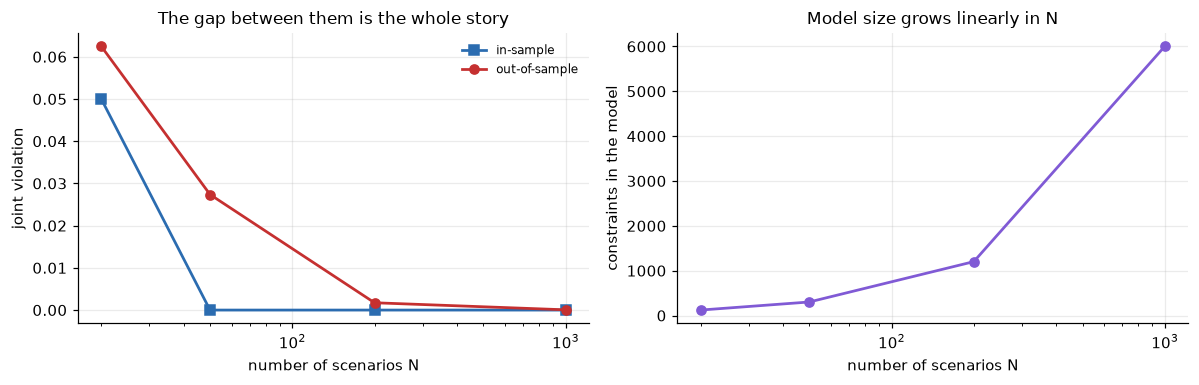

In [14]:
sample_sizes = [20, 50, 200, 1000] if not fast_mode() else [20, 50, 200]


def scenario_dispatch(scenarios):
    """Enforce every generator limit on every sampled realisation."""
    m = pyo.ConcreteModel(name="scenario dispatch")
    m.G = pyo.Set(initialize=range(N_BUS))
    m.S = pyo.Set(initialize=range(len(scenarios)))
    m.p = pyo.Var(m.G, bounds=lambda m, g: (0.0, GEN_MAX[g]))
    m.alpha = pyo.Var(m.G, bounds=(0.0, 1.0))

    net_demand = DEMAND.sum() - WIND_FORECAST
    m.balance = pyo.Constraint(expr=sum(m.p[g] for g in m.G) == net_demand)
    m.participation = pyo.Constraint(expr=sum(m.alpha[g] for g in m.G) == 1.0)

    totals = scenarios @ BALANCE

    @m.Constraint(m.G, m.S)
    def upper_scenario(m, g, s):
        return m.p[g] + m.alpha[g] * totals[s] <= GEN_MAX[g]

    @m.Constraint(m.G, m.S)
    def lower_scenario(m, g, s):
        return m.p[g] + m.alpha[g] * totals[s] >= 0.0

    m.cost = pyo.Objective(expr=sum(GEN_COST[g] * m.p[g] for g in m.G),
                           sense=pyo.minimize)
    return m


def measure(model, scenarios):
    totals = scenarios @ BALANCE
    p0 = np.array([pyo.value(model.p[g]) for g in model.G])
    alpha = np.array([pyo.value(model.alpha[g]) for g in model.G])
    realised = p0[None, :] + np.outer(totals, alpha)
    residuals = np.maximum(realised - GEN_MAX[None, :], -realised)
    return empirical_violation(residuals)


out_of_sample = sample_scenarios(uncertainty, N_VALIDATION, seed=24680)

# NESTED samples: draw the largest set once and take prefixes, so that
# S_20 subset S_50 subset S_200 subset S_1000. This is what makes the
# monotonicity below a theorem rather than a coincidence -- more scenarios then
# means strictly more constraints on the SAME realisations, so the feasible set
# can only shrink and the cost can only rise.
#
# Drawing an independent sample per N (seed = 1000 + n) does not give nested
# sets, and the cost is then free to fall when a larger sample happens to miss
# an extreme draw that a smaller one contained. The validation cell below
# asserted monotonicity regardless, and passed only because the particular
# draws happened to cooperate.
all_training = sample_scenarios(uncertainty, max(sample_sizes), seed=1000)

rows = []
for n in sample_sizes:
    training = all_training[:n]
    m = scenario_dispatch(training)
    rec = solve(m, "LP")
    if not rec.ok:
        rows.append({"N": n, "cost": np.nan, "status": rec.termination})
        continue
    inside = measure(m, training)
    outside = measure(m, out_of_sample)
    rows.append({
        "N": n, "cost": rec.objective,
        "in-sample JOINT": inside.joint,
        "out-of-sample JOINT": outside.joint,
        "constraints": rec.n_constraints,
        "seconds": rec.seconds,
    })

scenario_study = pd.DataFrame(rows).set_index("N")
display(scenario_study.round(5))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
valid = scenario_study.dropna(subset=["cost"])
axes[0].semilogx(valid.index, valid["in-sample JOINT"], "s-",
                 label="in-sample", color=COLORS["feasible"])
axes[0].semilogx(valid.index, valid["out-of-sample JOINT"], "o-",
                 label="out-of-sample", color=COLORS["infeasible"])
axes[0].set_xlabel("number of scenarios N")
axes[0].set_ylabel("joint violation")
axes[0].set_title("The gap between them is the whole story")
axes[0].legend(fontsize=8)
axes[1].semilogx(valid.index, valid["constraints"], "o-", color=COLORS["accent"])
axes[1].set_xlabel("number of scenarios N")
axes[1].set_ylabel("constraints in the model")
axes[1].set_title("Model size grows linearly in N")
fig.tight_layout()
plt.show()

In [15]:
assert scenario_study is not None, "build the `scenario_study` table first"
_v = scenario_study.dropna(subset=["cost"]).sort_index()
assert (_v["constraints"].diff().dropna() > 0).all(), "more scenarios, more constraints"
assert (_v["cost"].diff().dropna() >= -1e-6).all(), (
    "enforcing more scenarios adds constraints, so cost cannot fall"
)

# The optimism gap must be large at small N. It is NOT asserted to persist at
# large N: once both rates are order 1e-3, a single violation in the training
# sample moves the in-sample figure by 1/N, and the two become statistically
# indistinguishable. Asserting an ordering there would be testing noise.
_smallest = _v.iloc[0]
_gap_small = _smallest["out-of-sample JOINT"] - _smallest["in-sample JOINT"]
assert _gap_small > 1e-3, (
    f"at N={_v.index[0]} the in-sample estimate should be visibly optimistic, "
    f"gap was {_gap_small:.2e}"
)
_gap_large = abs(_v.iloc[-1]["out-of-sample JOINT"] - _v.iloc[-1]["in-sample JOINT"])
assert _gap_large < _gap_small, "the optimism gap should shrink as N grows"
print(f"Checks passed: optimism gap {_gap_small:.4f} at N={_v.index[0]} "
      f"-> {_gap_large:.4f} at N={_v.index[-1]}.")

Checks passed: optimism gap 0.0125 at N=20 -> 0.0001 at N=1000.


#### Interpretation

**Do more scenarios make a better formulation?**

In [16]:
first, last = _v.iloc[0], _v.iloc[-1]
print("ANSWER. They make a better ESTIMATE, which is not the same thing.")
print()
print(f"In-sample joint violation went {first['in-sample JOINT']:.4f} -> "
      f"{last['in-sample JOINT']:.4f}.")
print(f"Out-of-sample went {first['out-of-sample JOINT']:.4f} -> "
      f"{last['out-of-sample JOINT']:.4f}.")
print()
print("The in-sample number is near zero by CONSTRUCTION: the model enforced")
print("every one of those scenarios, so of course it satisfies them. Reporting")
print("it as a reliability figure is the optimization equivalent of scoring a")
print("model on its training set.")
print()
print("What more scenarios actually buy:")
print("  - a less optimistic estimate of true performance;")
print("  - with the scenario-approach theory of Calafiore and Campi, an explicit")
print("    confidence statement relating N, the number of decision variables and")
print("    the violation level.")
print()
print("What they do NOT buy:")
print(f"  - a smaller model. Constraints went {first['constraints']:.0f} -> "
      f"{last['constraints']:.0f}, linear in N.")
print("  - protection from a wrong DISTRIBUTION. Every sample here came from the")
print("    same Gaussian. If reality is skewed or fat-tailed, a million samples")
print("    from the wrong distribution give a precise answer to the wrong")
print("    question.")
print()
print("That last point is the one worth carrying away. Sampling error shrinks")
print("like 1/sqrt(N). Model error does not shrink at all.")

ANSWER. They make a better ESTIMATE, which is not the same thing.

In-sample joint violation went 0.0500 -> 0.0000.
Out-of-sample went 0.0625 -> 0.0001.

The in-sample number is near zero by CONSTRUCTION: the model enforced
every one of those scenarios, so of course it satisfies them. Reporting
it as a reliability figure is the optimization equivalent of scoring a
model on its training set.

What more scenarios actually buy:
  - a less optimistic estimate of true performance;
  - with the scenario-approach theory of Calafiore and Campi, an explicit
    confidence statement relating N, the number of decision variables and
    the violation level.

What they do NOT buy:
  - a smaller model. Constraints went 122 -> 6002, linear in N.
  - protection from a wrong DISTRIBUTION. Every sample here came from the
    same Gaussian. If reality is skewed or fat-tailed, a million samples
    from the wrong distribution give a precise answer to the wrong
    question.

That last point is the one wor

## 7. Key takeaways

1. **A chance constraint is a probability statement**, not a multiplied limit.
2. **The analytical reformulation is exact only for linear $g$ and Gaussian
   $\xi$.** State the assumption whenever you report the result.
3. **The safety margin is quantile $\times$ spread**, and the spread depends
   on the covariance — so correlation is a first-class input.
4. **Individual reliability is not joint reliability.** Measured here, three
   constraints at 5% each gave a joint violation several times higher.
5. **Boole's inequality converts a joint requirement into individual budgets**
   with a distribution-free guarantee, and pays for it in conservatism.
6. **Validate out of sample, with a confidence interval.** In-sample violation
   is a training-set score.

## Further reading

- Bienstock, Chertkov & Harnett, "Chance-constrained optimal power flow: risk-
  aware network control under uncertainty", *SIAM Review* 56(3), 2014.
- Roald & Andersson, "Chance-constrained AC optimal power flow: reformulations
  and efficient algorithms", *IEEE Trans. Power Syst.* 33(3), 2018.
- Vrakopoulou, Margellos, Lygeros & Andersson, "A probabilistic framework for
  reserve scheduling and N-1 security assessment", *IEEE Trans. Power Syst.*
  28(4), 2013.
- Calafiore & Campi, "The scenario approach to robust control design", *IEEE
  Trans. Autom. Control* 51(5), 2006.

## Next

Tutorial 08 notices that scenarios decompose: fix the first-stage decision and
every scenario becomes an independent subproblem. That is Benders.